# Imports

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from functools import reduce
import seaborn as sns
import re
import unicodedata
import json

# Read Data File

In [2]:
file = "FatigueData-AM2022.xlsx"

# read all sheets
all_sheets = pd.read_excel(file, sheet_name=None, header=0)

print(all_sheets.keys())

dict_keys(['S-N', 'e-N', 'dadn', 'parameter'])


In [3]:
for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):

    print(f"\nDataset {i}")
    print("Sheet:", sheet_name)
    print(df.columns.tolist())


Dataset 1
Sheet: S-N
['dataset id', 'life\nN (cycle)', 'stress amplitude\nσa (MPa)', 'runout']

Dataset 2
Sheet: e-N
['dataset id', 'life\nN (cycle)', 'strain amplitude\nεa (mm/mm)', 'runout']

Dataset 3
Sheet: dadn
['dataset id', 'stress intensity factor range\nΔK (MPa*m^(1/2))', 'crack growth rate \nda/dn (m/cycle)']

Dataset 4
Sheet: parameter
['Unnamed: 0', 'metadata', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'fatigue', 'Unnamed: 10', 'materials', 'AM', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'processing', 'testing', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'static mechanical properties', 'Unnamed: 43', 'Un

In [4]:
for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):

    print("\n" + "="*60)
    print(f"Sheet {i}: {sheet_name}")
    print("="*60)

    print(df.describe())

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    # print("\nFirst rows:")
    # print(df.head())

    print("\nMissing values:")
    print(df.isnull().sum())


Sheet 1: S-N
         dataset id  life\nN (cycle)  stress amplitude\nσa (MPa)       runout
count  15146.000000     1.514600e+04                15146.000000  15146.00000
mean     792.986003     1.844821e+07                  285.818193      0.12221
std      457.581397     1.472127e+08                  189.421194      0.32754
min        1.000000     9.710731e+00                    5.760575      0.00000
25%      396.000000     6.502688e+04                  138.464799      0.00000
50%      780.000000     2.443496e+05                  249.958188      0.00000
75%     1187.000000     1.599869e+06                  375.990143      0.00000
max     1610.000000     8.496147e+09                 1591.682267      1.00000

Shape:
(15146, 4)

Columns:
['dataset id', 'life\nN (cycle)', 'stress amplitude\nσa (MPa)', 'runout']

Missing values:
dataset id                    0
life\nN (cycle)               0
stress amplitude\nσa (MPa)    0
runout                        0
dtype: int64

Sheet 2: e-N
        d

# Clean Column Names

## Remove Merged Headers
remove merged headers in row 1 of "parameters" and make row 2 the header row

In [5]:
# reread only the parameter sheet with row 2 as header
all_sheets["parameter"] = pd.read_excel(
    file,
    sheet_name="parameter",
    header=1
)

The "parameters" sheet includes many missing values. The others include none. 

## Merged Sheets
merge all the sheets where possible on dataset id

In [6]:
dfs = []

for sheet_name, sheet_df in all_sheets.items():
    sheet_df = sheet_df.copy()

    # standardize dataset id column before merge
    sheet_df.columns = [
        str(col).strip().lower().replace(" ", "_")
        for col in sheet_df.columns
    ]

    # make sure dataset_id is consistent
    sheet_df = sheet_df.rename(columns={
        "dataset_id": "dataset_id",
        "datasetid": "dataset_id",
        "dataset_id_": "dataset_id",
        "dataset": "dataset_id"
    })

    dfs.append(sheet_df)

merged_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="dataset_id",
        how="outer",
        suffixes=("", "_dup")
    ),
    dfs
)

print(merged_df.shape)
print(merged_df.columns.tolist())

(195047, 55)
['dataset_id', 'life\nn_(cycle)', 'stress_amplitude\nσa_(mpa)', 'runout', 'life\nn_(cycle)_dup', 'strain_amplitude\nεa_(mm/mm)', 'runout_dup', 'stress_intensity_factor_range\nδk_(mpa*m^(1/2))', 'crack_growth_rate_\nda/dn_(m/cycle)', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_\n(w)', 'scan_speed_\n(mm/s)', 'hatch_space_\n(μm)', 'layer_thickness_\n(μm)', 'preheat_temperature_\n(°c)', 'direciton_of_specimen_\n(°)', 'am_environment', 'scan_pattern', 'layer_scan_rotation_\n(°)', 'voltage_\n(v)', 'current_\n(a)', 'speed_function', 'powder_feed_rate_\n(g/s)', 'wire_feed_rate_\n(mm/s)', 'types_of_feedstock', 'size_of_feedstock_\n(μm)', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_\n(°c)', 'fatigue_environment', 'load_ratio', 'frequency_\n(hz)', 

## Clean Column Names
clean merged dataframe

In [19]:
def clean_column_name(col):
    col = str(col)

    symbol_map = {
        "σ": "sigma",
        "Δ": "delta",
        "µ": "micro",
        "√": "sqrt",
        "ε": "epsilon",
    }

    for symbol, replacement in symbol_map.items():
        col = col.replace(symbol, replacement)

    col = unicodedata.normalize("NFKD", col)
    col = col.encode("ascii", "ignore").decode()
    col = col.strip().lower()
    col = col.replace(" ", "_").replace("/", "_")
    col = re.sub(r"[^a-z0-9_]", "", col)
    col = re.sub(r"_+", "_", col)
    col = col.strip("_")
    col = col.replace("\n", "").replace("_x", "") 

    return col

clean_merged_df = merged_df.copy()
clean_merged_df.columns = [
    clean_column_name(col)
    for col in clean_merged_df.columns
]

# fix known typo
clean_merged_df = clean_merged_df.rename(columns={
    "direciton_of_specimen": "direction_of_specimen",
    "lifen_cycle": "lifecycle_n"
})

print(clean_merged_df.columns.tolist())

['dataset_id', 'lifecycle_n', 'stress_amplitudesigmaa_mpa', 'runout', 'lifen_cycle_dup', 'strain_amplitudeepsilona_mm_mm', 'runout_dup', 'stress_intensity_factor_rangek_mpam1_2', 'crack_growth_rate_da_dn_m_cycle', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direction_of_specimen', 'am_environment', 'scan_pattern', 'layer_scan_rotation', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_g_s', 'wire_feed_rate_mm_s', 'types_of_feedstock', 'size_of_feedstock_m', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimens_description', 'critical_crossse

## Remove Columns
remove irrelevant or duplicate columns

In [20]:
# find duplicate columns created during merge
dup_cols = [col for col in clean_merged_df.columns
            if "_dup" in col]

cols_to_drop = [
    "runout",
    "title",
    "authors",
    "source_of_the_publication",
    "year_of_publication",
    "institution",
    "country_and_region",
    "funding_agency",
    "doi",
    "rating_score",
    "runout_y",
    "lifen_cycle_y",
]

# combine lists
cols_to_drop.extend(dup_cols)

# drop columns
clean_merged_df = clean_merged_df.drop(
    columns=cols_to_drop,
    errors="ignore"
)

print(clean_merged_df.columns.to_list())

['dataset_id', 'lifecycle_n', 'stress_amplitudesigmaa_mpa', 'strain_amplitudeepsilona_mm_mm', 'stress_intensity_factor_rangek_mpam1_2', 'crack_growth_rate_da_dn_m_cycle', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direction_of_specimen', 'am_environment', 'scan_pattern', 'layer_scan_rotation', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_g_s', 'wire_feed_rate_mm_s', 'types_of_feedstock', 'size_of_feedstock_m', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimens_description', 'critical_crosssection_size_of_specimensmm', 'stress_concentration_factor_of_specimens', 'youngs_modulus_gpa', 'yield_strength_mpa', 'ultimate_tensile_strength_mpa', 'elongation']


In [21]:
# create a dataframe, workflow_df, with only the necessary columns
irrel_cols = ['method_of_extraction',
              'voltage_v',
              'current_a',
              'speed_function',
              'powder_feed_rate_g_s',
              'wire_feed_rate_mm_s',
              'types_of_feedstock',
              'size_of_feedstock_m',
              'processing_sequence_and_parameters',
              'types_of_fatigue_tests',
              'fatigue_machine',
              'fatigue_standard'
]

workflow_df = clean_merged_df.copy()

# drop columns
workflow_df = workflow_df.drop(
    columns=irrel_cols,
    errors="ignore"
)

print(workflow_df.columns.to_list())

['dataset_id', 'lifecycle_n', 'stress_amplitudesigmaa_mpa', 'strain_amplitudeepsilona_mm_mm', 'stress_intensity_factor_rangek_mpam1_2', 'crack_growth_rate_da_dn_m_cycle', 'types_of_fatigue_data', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direction_of_specimen', 'am_environment', 'scan_pattern', 'layer_scan_rotation', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'load_control', 'specimens_description', 'critical_crosssection_size_of_specimensmm', 'stress_concentration_factor_of_specimens', 'youngs_modulus_gpa', 'yield_strength_mpa', 'ultimate_tensile_strength_mpa', 'elongation']


## Standarize Column Names
standarize column names in workflow dataframe

In [22]:
# standardize selected columns in workflow_df

rename_map = {

    # target
    "lifecycle_n": "Nf",

    # loading
    "stress_amplitudesigmaa_mpa": "stress_amp",
    "strain_amplitudeepsilona_mm_mm": "strain_amp",
    "load_ratio": "r_ratio",
    "frequency_hz": "frequency_hz",
    "load_control": "load_control",

    # fracture mechanics
    "stress_intensity_factor_rangek_mpam1_2": "deltaK",
    "crack_growth_rate_da_dn_m_cycle": "dadN",

    # material
    "name_of_the_material": "material",
    "youngs_modulus_gpa": "E_gpa",
    "yield_strength_mpa": "yield_strength",
    "ultimate_tensile_strength_mpa": "uts",
    "elongation": "elongation",

    # additive manufacturing process
    "types_of_am": "am_process",
    "am_machine": "am_machine",
    "power_w": "power_w",
    "scan_speed_mm_s": "scan_speed",
    "hatch_space_m": "hatch_spacing",
    "layer_thickness_m": "layer_thickness",
    "preheat_temperature_c": "preheat_temp",

    # build/specimen
    "direction_of_specimen": "build_direction",
    "critical_crosssection_size_of_specimensmm": "specimen_size_mm",
    "stress_concentration_factor_of_specimens": "Kt",

    # environments
    "am_environment": "am_environment",
    "fatigue_environment": "fatigue_environment",
    "fatigue_temperature_c": "fatigue_temp",

    # scan strategy
    "scan_pattern": "scan_pattern",
    "layer_scan_rotation": "scan_rotation",

    # metadata
    "types_of_fatigue_data": "fatigue_data_type",
    "specimens_description": "specimen_description",
}

workflow_df = workflow_df.rename(columns=rename_map)

print(workflow_df.columns.tolist())

['dataset_id', 'Nf', 'stress_amp', 'strain_amp', 'deltaK', 'dadN', 'fatigue_data_type', 'material', 'am_process', 'am_machine', 'power_w', 'scan_speed', 'hatch_spacing', 'layer_thickness', 'preheat_temp', 'build_direction', 'am_environment', 'scan_pattern', 'scan_rotation', 'fatigue_temp', 'fatigue_environment', 'r_ratio', 'frequency_hz', 'load_control', 'specimen_description', 'specimen_size_mm', 'Kt', 'E_gpa', 'yield_strength', 'uts', 'elongation']


## Final Working Dataframe
final, merged dataframe with clean column names to deal with missing values

In [27]:
df = workflow_df.copy()

print(df.columns.tolist())
df.head()

['dataset_id', 'Nf', 'stress_amp', 'strain_amp', 'deltaK', 'dadN', 'fatigue_data_type', 'material', 'am_process', 'am_machine', 'power_w', 'scan_speed', 'hatch_spacing', 'layer_thickness', 'preheat_temp', 'build_direction', 'am_environment', 'scan_pattern', 'scan_rotation', 'fatigue_temp', 'fatigue_environment', 'r_ratio', 'frequency_hz', 'load_control', 'specimen_description', 'specimen_size_mm', 'Kt', 'E_gpa', 'yield_strength', 'uts', 'elongation']


,dataset_id,Nf,stress_amp,strain_amp,deltaK,dadN,fatigue_data_type,material,am_process,am_machine,...,r_ratio,frequency_hz,load_control,specimen_description,specimen_size_mm,Kt,E_gpa,yield_strength,uts,elongation
0,1,20047.798627,233.965265,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
1,1,50630.187289,215.905854,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
2,1,94372.343349,197.999439,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
3,1,152595.813892,180.016661,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
4,1,270549.972140,161.845026,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2


# Clean Data

In [28]:
# quick overview
print(df.shape)
print(df.dtypes)
print(clean_merged_df.isnull().sum().sort_values(ascending=False))

(195047, 31)
dataset_id                int64
Nf                      float64
stress_amp              float64
strain_amp              float64
deltaK                  float64
dadN                    float64
fatigue_data_type        object
material                 object
am_process               object
am_machine               object
power_w                  object
scan_speed               object
hatch_spacing            object
layer_thickness          object
preheat_temp             object
build_direction          object
am_environment           object
scan_pattern             object
scan_rotation           float64
fatigue_temp              int64
fatigue_environment      object
r_ratio                  object
frequency_hz             object
load_control             object
specimen_description     object
specimen_size_mm         object
Kt                      float64
E_gpa                   float64
yield_strength          float64
uts                     float64
elongation              flo

## Remove Empty & Duplicate Rows
remove fully empty rows and duplicate values

In [29]:
# remove fully empty rows
df = df.dropna(how="all")

# remove duplicate rows
df = df.drop_duplicates()

print(df.shape)

(193890, 31)


Shape reduced (195047, 31) to (193890, 31) so almost 2,000 rows were removed.

## Clean Text Columns

In [30]:
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    )

## Clean Numeric Columns

In [31]:
numeric_cols = [
    "Nf",
    "stress_amp",
    "strain_amp",
    "deltaK",
    "dadN",
    "power_w",
    "scan_speed",
    "hatch_spacing",
    "layer_thickness",
    "preheat_temp",
    "fatigue_temp",
    "r_ratio",
    "frequency_hz",
    "specimen_size_mm",
    "Kt",
    "E_gpa",
    "yield_strength",
    "uts",
    "elongation",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

## Replace Impossible Values
replace physically impossible values

In [32]:
positive_cols = [
    "Nf",
    "stress_amp",
    "deltaK",
    "dadN",
    "power_w",
    "scan_speed",
    "hatch_spacing",
    "layer_thickness",
    "frequency_hz",
    "Kt",
    "E_gpa",
    "yield_strength",
    "uts",
]

for col in positive_cols:
    if col in df.columns:
        df.loc[df[col] <= 0, col] = pd.NA

## Missing Values
missing values in relevant columns are handled

In [33]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

strain_amp              192175
specimen_size_mm        182828
stress_amp              178782
Nf                      178782
E_gpa                   156889
scan_pattern            155402
preheat_temp            151620
scan_rotation           133210
am_environment          116054
hatch_spacing            99961
elongation               88232
yield_strength           84419
uts                      82687
power_w                  74210
scan_speed               73199
layer_thickness          51838
frequency_hz             49236
am_machine               26483
dadN                     16823
deltaK                   16823
build_direction          14271
r_ratio                   7927
specimen_description      1161
dtype: int64


### Fatigue Life Data
drop rows without Nf

In [34]:
df_life = df.dropna(subset=["Nf", "stress_amp"])

print(df_life.shape)
df_life.head()

(15108, 31)


,dataset_id,Nf,stress_amp,strain_amp,deltaK,dadN,fatigue_data_type,material,am_process,am_machine,...,r_ratio,frequency_hz,load_control,specimen_description,specimen_size_mm,Kt,E_gpa,yield_strength,uts,elongation
0,1,20047.798627,233.965265,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10.0,force,circular cross-section; with drawing,3.0,1.0,NaN,490.0,656.0,48.2
1,1,50630.187289,215.905854,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10.0,force,circular cross-section; with drawing,3.0,1.0,NaN,490.0,656.0,48.2
2,1,94372.343349,197.999439,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10.0,force,circular cross-section; with drawing,3.0,1.0,NaN,490.0,656.0,48.2
3,1,152595.813892,180.016661,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10.0,force,circular cross-section; with drawing,3.0,1.0,NaN,490.0,656.0,48.2
4,1,270549.972140,161.845026,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10.0,force,circular cross-section; with drawing,3.0,1.0,NaN,490.0,656.0,48.2


### Crack Growth Data
drop rows without daDN

In [35]:
df_crack = df.dropna(subset=["deltaK", "dadN"])

print(df_crack.shape)
df_crack.head()

(177067, 31)


,dataset_id,Nf,stress_amp,strain_amp,deltaK,dadN,fatigue_data_type,material,am_process,am_machine,...,r_ratio,frequency_hz,load_control,specimen_description,specimen_size_mm,Kt,E_gpa,yield_strength,uts,elongation
16986,1847,NaN,NaN,NaN,3.893058,5.309420e-10,dadn,Ti-6Al-4V,L-PBF,3D Systems ProX DMP 320,...,0.05,10.0,load,C(T); with drawing,<NA>,1.0,120.0,950.0,1144.0,NaN
16987,1847,NaN,NaN,NaN,12.649111,3.640871e-08,dadn,Ti-6Al-4V,L-PBF,3D Systems ProX DMP 320,...,0.05,10.0,load,C(T); with drawing,<NA>,1.0,120.0,950.0,1144.0,NaN
16988,1847,NaN,NaN,NaN,10.572607,1.529528e-08,dadn,Ti-6Al-4V,L-PBF,3D Systems ProX DMP 320,...,0.05,10.0,load,C(T); with drawing,<NA>,1.0,120.0,950.0,1144.0,NaN
16989,1847,NaN,NaN,NaN,20.579883,1.933091e-07,dadn,Ti-6Al-4V,L-PBF,3D Systems ProX DMP 320,...,0.05,10.0,load,C(T); with drawing,<NA>,1.0,120.0,950.0,1144.0,NaN
16990,1847,NaN,NaN,NaN,7.513516,7.478646e-09,dadn,Ti-6Al-4V,L-PBF,3D Systems ProX DMP 320,...,0.05,10.0,load,C(T); with drawing,<NA>,1.0,120.0,950.0,1144.0,NaN


### Final Clean Dataframe

In [36]:
clean_df = df.copy()

print(clean_df.shape)
print(clean_df.columns.tolist())
clean_df.head()

(193890, 31)
['dataset_id', 'Nf', 'stress_amp', 'strain_amp', 'deltaK', 'dadN', 'fatigue_data_type', 'material', 'am_process', 'am_machine', 'power_w', 'scan_speed', 'hatch_spacing', 'layer_thickness', 'preheat_temp', 'build_direction', 'am_environment', 'scan_pattern', 'scan_rotation', 'fatigue_temp', 'fatigue_environment', 'r_ratio', 'frequency_hz', 'load_control', 'specimen_description', 'specimen_size_mm', 'Kt', 'E_gpa', 'yield_strength', 'uts', 'elongation']


,dataset_id,Nf,stress_amp,strain_amp,deltaK,dadN,fatigue_data_type,material,am_process,am_machine,...,r_ratio,frequency_hz,load_control,specimen_description,specimen_size_mm,Kt,E_gpa,yield_strength,uts,elongation
0,1,20047.798627,233.965265,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10.0,force,circular cross-section; with drawing,3.0,1.0,NaN,490.0,656.0,48.2
1,1,50630.187289,215.905854,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10.0,force,circular cross-section; with drawing,3.0,1.0,NaN,490.0,656.0,48.2
2,1,94372.343349,197.999439,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10.0,force,circular cross-section; with drawing,3.0,1.0,NaN,490.0,656.0,48.2
3,1,152595.813892,180.016661,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10.0,force,circular cross-section; with drawing,3.0,1.0,NaN,490.0,656.0,48.2
4,1,270549.972140,161.845026,NaN,NaN,NaN,sn,316L,L-PBF,Aconity MINI,...,0.1,10.0,force,circular cross-section; with drawing,3.0,1.0,NaN,490.0,656.0,48.2


# Exploratory Data Analysis

In [38]:
print(clean_df.describe())

          dataset_id            Nf    stress_amp   strain_amp         deltaK  \
count  193890.000000  1.510800e+04  15108.000000  1715.000000  177067.000000   
mean     2040.383785  1.848177e+07    286.011147     0.005500      17.868358   
std       416.891004  1.473960e+08    189.530859     0.004285      15.261925   
min         1.000000  9.710731e+00      5.760575     0.000601       0.222404   
25%      1971.000000  6.474727e+04    138.396373     0.002985       7.009729   
50%      2108.000000  2.427192e+05    249.975229     0.004294      13.395579   
75%      2283.000000  1.591638e+06    376.017345     0.007291      23.847268   
max      2460.000000  8.496147e+09   1591.682267     0.040115     120.063712   

               dadN      power_w  scan_speed  hatch_spacing  layer_thickness  \
count  1.770670e+05     119680.0    120691.0        93929.0         142052.0   
mean   5.734740e-07  1039.410411  629.113841     330.144274       164.566919   
std    2.361138e-06  1703.486492  604.4

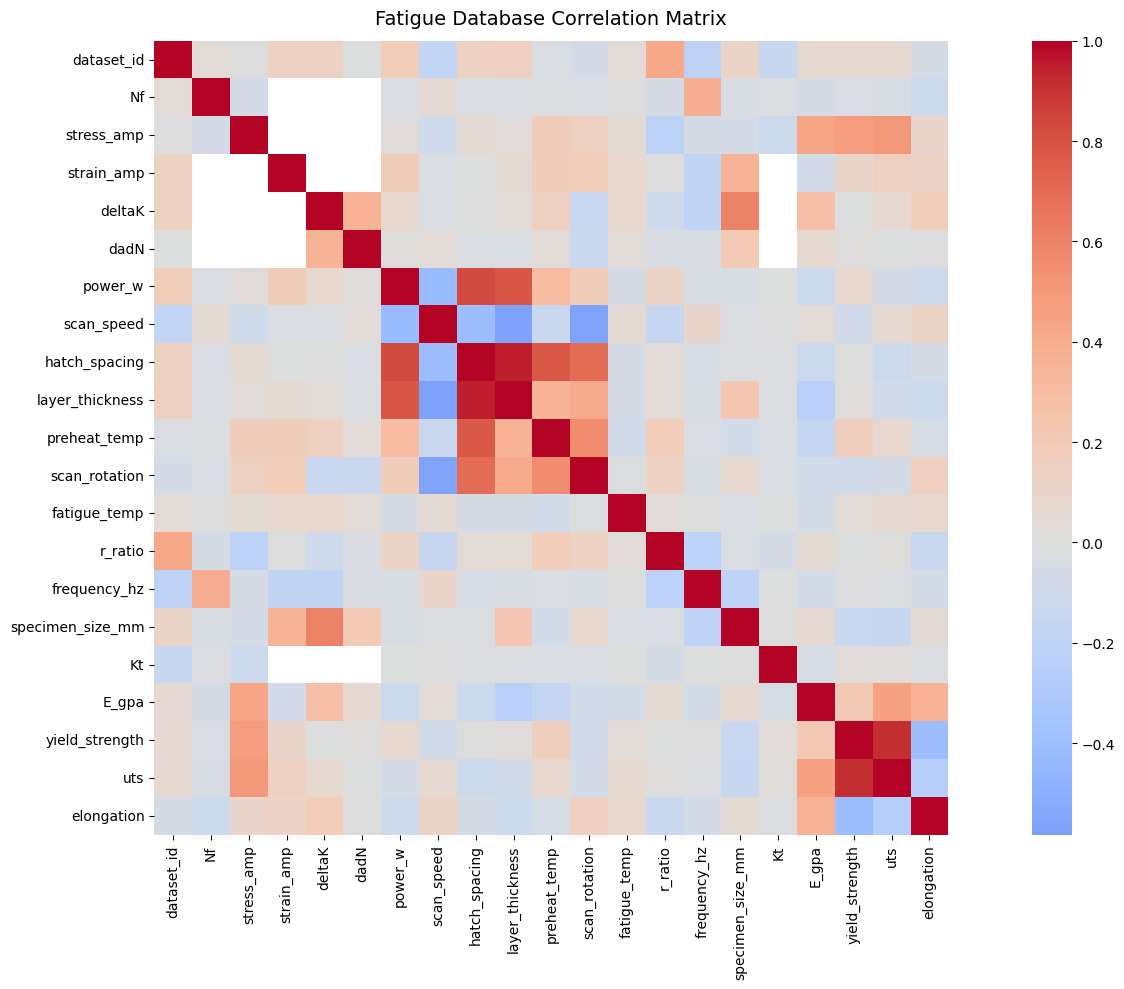

In [ ]:
corr = clean_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            square=True,
            #annot=True,
            )
plt.title('Fatigue Database Correlation Matrix',
          fontdict={'fontsize':14}, pad=12)
plt.tight_layout()
plt.show()

Power, scan speed, hatch spacing, layer thickness, and temperature are all highly correlated. This is expected since they are all process parameters involved in the the VED and thus the number of defects.

Expectedly, the Young's modulus, yield strength, UTS, and elongation are all highly correlated.

# Export Clean Sheet

In [56]:
clean_df.to_excel("fatigue_database_clean.xlsx", index=False)